# Fig S3 — Gene–protein validation, PCA, residuals, HLA associations, and classifier tSNE

Execute cells in order.

Set `DLBCL_DATA_DIR` before the setup cell to override the data root.
Example: `DLBCL_DATA_DIR = '/path/to/data'`

In [1]:
%matplotlib inline

import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dlbcl.notebook_setup import run_notebook_setup

_ctx = run_notebook_setup('validation_and_discovery', 'supplemental_fig3')
REPO_ROOT = _ctx.repo_root
_paths = _ctx.paths
FIG_DIR = _ctx.fig_dir
adata = _ctx.adata
arch_df = _ctx.arch_df
pred = _ctx.pred
gep = _ctx.gep
surv = _ctx.surv
archetype_label = _ctx.archetype_label
PATIENT_SUBSET = _ctx.patient_subset
OUTDIR = FIG_DIR
OUTDIR.mkdir(parents=True, exist_ok=True)

# Override data root: export DLBCL_DATA_DIR=/path/to/data before running.
print(f"AnnData: {_paths.adata_path}")
print(f"Figures: {FIG_DIR}")

import gc

import pandas as pd
import scanpy as sc

ADATA_PATH = _paths.adata_path

# tSNE panel constants and filtered single-cell subset.
import gc

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

from dlbcl.dlbcl_io import consolidate_embedded_case_classifications, log_wrote, log_saved, rel_path
from dlbcl.phenotype_labels import ensure_phenotype_30_labels, read_celltype_colormap_30
from dlbcl.tsne_figures import show_inline_preview

DATA_DIR = _paths.data_dir
ADATA_PATH = _paths.adata_path
ARCH_PATH = _paths.arch_path
FILTERING_STATUS_COL = "filtering_status"
FILTERING_KEEP_VALUE = "Unfiltered"
TSNE_BASIS = "tsne_all"
DOWNSAMPLE_FRAC = 1
PLOT_SEED = 42
INLINE_PREVIEW_DPI = 96
INLINE_PREVIEW_MAX_WIDTH = 900
INLINE_PREVIEW_JPEG_QUALITY = 72

import math
import re

from scipy import sparse

IMC_LAYER = "sum_unhuddle"
GENE_TO_PROTEIN = {
    "CD3E": "CD3", "CD3G": "CD3", "CD4": "CD4", "CD8A": "CD8a", "FOXP3": "FOXP3",
    "IDO1": "IDO", "GZMB": "GranzymeB", "LAG3": "LAG3", "MS4A1": "CD20", "TBX21": "Tbet",
    "PDCD1": "PD1", "VSIR": "VISTA", "ACTA2": "SMA", "TIGIT": "TIGIT", "CD163": "CD163",
    "HLA-DRB1": "HLADR", "CD68": "CD68", "ICOS": "ICOS", "HAVCR2": "TIM3", "KI67": "Ki67",
    "ITGAX": "CD11c",
}
DROP_GENES = {"B2M", "HLA-A", "HLA-B"}

import dlbcl.transcriptome_de as tde

from dlbcl.tsne_figures import (
    configure_tsne_matplotlib,
    downsample_indices,
    map_patient_column,
    plot_tsne,
    sort_adata_by_obs_category,
    valid_label_mask,
)

configure_tsne_matplotlib()

adata_backed = ad.read_h5ad(_paths.adata_path, backed="r")
mask = (
    adata_backed.obs["patient_id"].isin(PATIENT_SUBSET)
    & (adata_backed.obs[FILTERING_STATUS_COL] == FILTERING_KEEP_VALUE)
)
adata_subset = adata_backed[mask].to_memory()
ensure_phenotype_30_labels(adata_subset)
ensure_phenotype_30_labels(adata)
del adata_backed
gc.collect()

if TSNE_BASIS not in adata_subset.obsm:
    raise KeyError(f"Missing obsm['{TSNE_BASIS}']; keys: {list(adata_subset.obsm.keys())}")

adata_subset = consolidate_embedded_case_classifications(
    adata_subset, _paths, repo_root=REPO_ROOT
)
print(
    f"Cells: {adata_subset.n_obs:,} | patients: {adata_subset.obs['patient_id'].nunique()}"
)

if "gene_expression" not in adata_subset.uns:
    raise KeyError("Expected adata_subset.uns['gene_expression']")

GE = adata_subset.uns["gene_expression"]
if not isinstance(GE, pd.DataFrame):
    raise TypeError("uns['gene_expression'] must be a DataFrame (genes × patients)")

from IPython.display import display
from dlbcl.dlbcl_io import log_wrote, log_saved, rel_path, write_supplementary_table
subset = None  # nb8 classifier associations: filtered AnnData or None for all patients

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from dlbcl.dlbcl_io import log_wrote, log_saved, write_supplementary_table, rel_path
import dlbcl.validation_figures as vf

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "DejaVu Sans"

# nb1 expression PCA constants (Fig S3B cells expect these names).
import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from dlbcl.dlbcl_io import load_discovery_metadata

ADATA_PATH = _paths.adata_path
RANDOM_SEED = 0
N_PCS_TO_FIT = 10
PLOT_PCS = [(1, 2), (1, 3)]

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "DejaVu Sans"

meta = load_discovery_metadata(adata_subset, PATIENT_SUBSET)
adata_subset.uns["gene_expression"] = GE.drop(index="EBER2", errors="ignore")
GE = adata_subset.uns["gene_expression"]


AnnData: /Users/troynoordenbos/code/public_repo/DLBCL_location_2026/data/DLBCL_location_2026.h5ad
Figures: /Users/troynoordenbos/code/public_repo/DLBCL_location_2026/figures/supplemental_fig3


Cells: 1,192,844 | patients: 64


## Fig S3 — panel overview

Panels follow manuscript order (S3A → S3B → S3C → S3D → S3E → S3F–H → S3J).

| Panel | Description |
|-------|-------------|
| S3A | Patient-level gene vs protein correlation (IMC) |
| S3B | PCA colored by anatomical location |
| S3C | Phenotype × location standardized residuals |
| S3D | HLA class status × immune gene programs |
| S3E | HLA class status × phenotypes |
| S3F | Cell-of-origin (COO) tSNE |
| S3G | lymphoMAP tSNE |
| S3H | Immune archetype tSNE |
| S3J | Elastic-net classifier confusion matrix — see **`fig5.ipynb`** (Fig 5H) |

**Data:** `data/DLBCL_location_2026.h5ad` — set `DLBCL_DATA_DIR` to override the data root.

## Fig S3A — gene vs protein correlation (patient level)

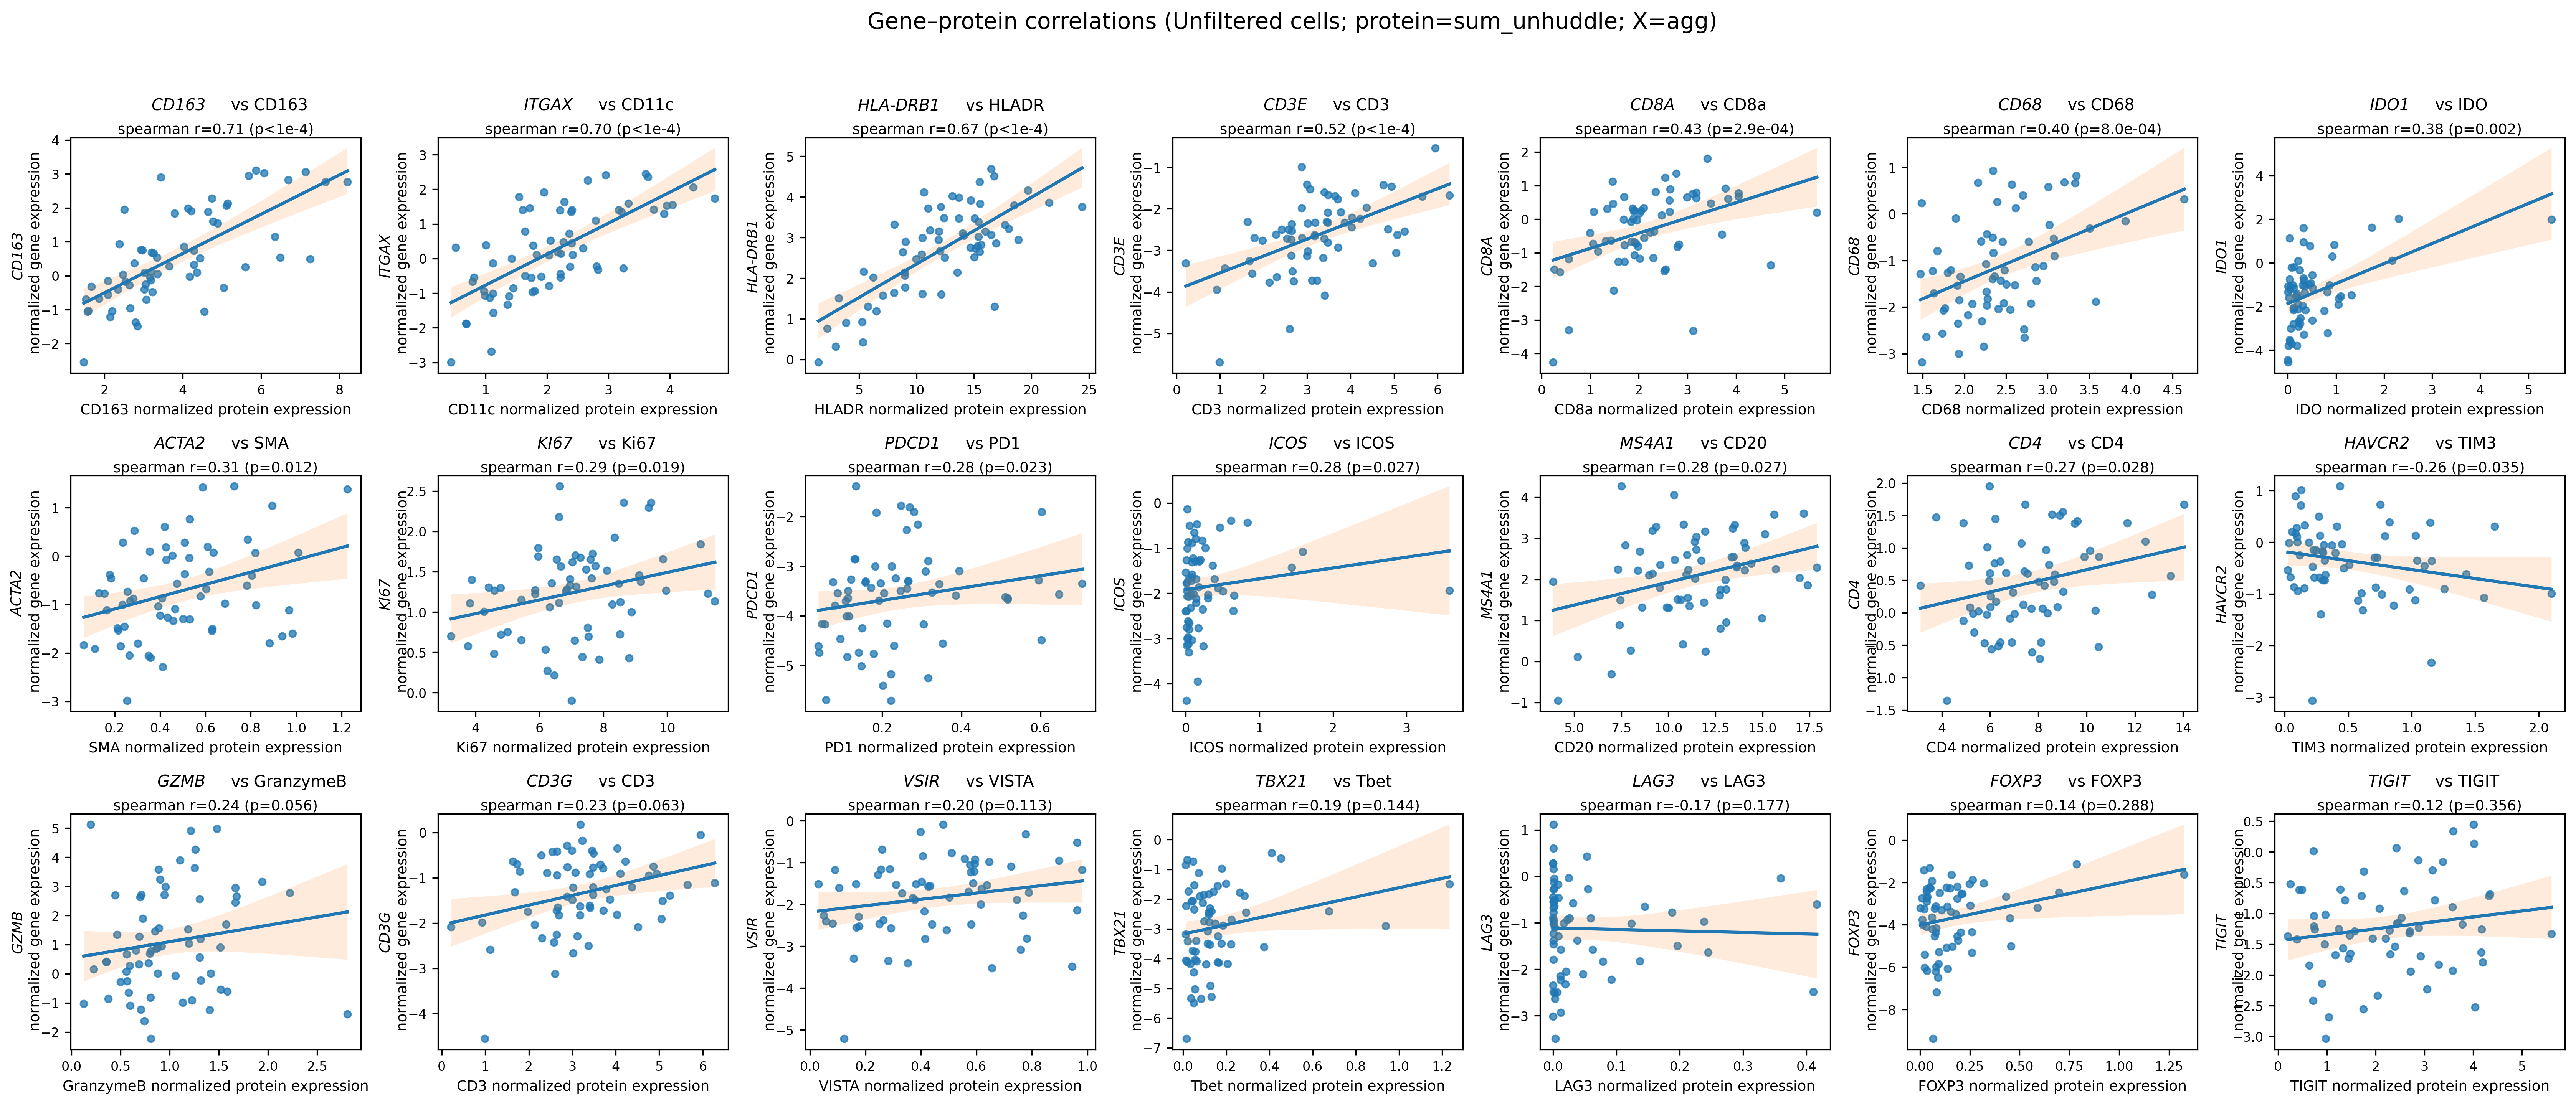

/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/figures/supplemental_fig3/figS3A_gene_protein_correlation_page01.svg


In [2]:
# S2A settings
X_MODE = "agg"          # "agg" or "fraction"
AGG = "mean"
MIN_CELLS_PER_PATIENT = 50
EPS = 1e-12
N_COLS, N_ROWS = 7, 3
FIGSIZE_PER_PANEL = 3.2
SORT_BY = "spearman_p"

def _as_dense(col):
    return col.toarray().ravel() if hasattr(col, "toarray") else np.asarray(col).ravel()

def _imc_matrix(adata, layer):
    if layer is None:
        return adata.X
    if layer not in adata.layers:
        raise KeyError(f"Layer '{layer}' not in adata.layers")
    return adata.layers[layer]

def _get_protein_col(adata, name, layer=IMC_LAYER):
    idx = np.where(adata.var_names == name)[0]
    if len(idx) == 0:
        raise KeyError(name)
    return _as_dense(_imc_matrix(adata, layer)[:, int(idx[0])])

def _agg_by_patient(values, groups, how):
    s = pd.Series(values, index=groups.index)
    return s.groupby(groups).mean() if how == "mean" else s.groupby(groups).median()

def _spearman_r_p(x, y):
    n = len(x)
    if n < 4:
        return np.nan, np.nan
    xr = pd.Series(x).rank(method="average").to_numpy()
    yr = pd.Series(y).rank(method="average").to_numpy()
    r = float(np.corrcoef(xr, yr)[0, 1])
    r = max(min(r, 1 - 1e-15), -1 + 1e-15)
    z = 0.5 * math.log((1 + r) / (1 - r)) * math.sqrt(n - 3)
    p = 2.0 * (1.0 - 0.5 * (1.0 + math.erf(abs(z) / math.sqrt(2.0))))
    return r, p

def _format_p(p):
    if not np.isfinite(p):
        return "p=NA"
    if p < 1e-4:
        return "p<1e-4"
    return f"p={p:.3f}" if p >= 0.001 else f"p={p:.1e}"

def _ols_ci(x, y, x_grid):
    x, y = np.asarray(x, float), np.asarray(y, float)
    n = len(x)
    if n < 3 or np.allclose(np.var(x), 0):
        return None, None, None
    xm, ym = x.mean(), y.mean()
    Sxx = np.sum((x - xm) ** 2)
    b = np.sum((x - xm) * (y - ym)) / Sxx
    a = ym - b * xm
    resid = y - (a + b * x)
    dof = n - 2
    if dof <= 0:
        return a + b * x_grid, None, None
    s = math.sqrt(np.sum(resid ** 2) / dof)
    se = s * np.sqrt(1.0 / n + (x_grid - xm) ** 2 / Sxx)
    yhat = a + b * x_grid
    return yhat, yhat - 1.96 * se, yhat + 1.96 * se

def _canon_gene(s):
    return re.sub(r"\s+", "", str(s).strip().upper().replace("_", "-"))

def _canon_protein(s):
    return re.sub(r"\s+", "", str(s).strip())

def _build_pairs(GE, adata, mapping, drop_genes):
    ge_lookup = {_canon_gene(g): g for g in GE.index.astype(str)}
    var_lookup = {_canon_protein(v): v for v in adata.var_names.astype(str)}
    pairs = []
    for gene_sym, protein_sym in mapping.items():
        if gene_sym in drop_genes:
            continue
        g_key = _canon_gene(gene_sym)
        if g_key not in ge_lookup:
            continue
        gene = ge_lookup[g_key]
        prot = None
        for cand in [protein_sym, f"protein_{protein_sym}", f"ADT_{protein_sym}"]:
            key = _canon_protein(cand)
            if key in var_lookup:
                prot = var_lookup[key]
                break
        if prot is not None:
            pairs.append((gene, prot))
    return pairs

def _panel_title(ax, gene, protein, r, p, xlabel):
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel("")
    ax.text(-0.18, 0.5, gene, transform=ax.transAxes, rotation=90, ha="center", va="center",
            fontsize=9, fontstyle="italic")
    ax.text(-0.12, 0.5, " normalized gene expression", transform=ax.transAxes, rotation=90,
            ha="center", va="center", fontsize=9)
    ax.set_title("")
    ax.text(0.5, 1.10, gene + "  ", transform=ax.transAxes, ha="right", va="bottom",
            fontsize=10, fontstyle="italic")
    ax.text(0.5, 1.10, f"   vs {protein}", transform=ax.transAxes, ha="left", va="bottom", fontsize=10)
    ax.text(0.5, 1.06, f"spearman r={r:.2f} ({_format_p(p)})", transform=ax.transAxes,
            ha="center", va="top", fontsize=9)
    ax.tick_params(labelsize=8)

pid_all = adata_subset.obs["patient_id"].astype(str)
is_unf = adata_subset.obs[FILTERING_STATUS_COL].astype(str) == FILTERING_KEEP_VALUE
counts = pid_all[is_unf].value_counts()
keep_pids = counts[counts >= MIN_CELLS_PER_PATIENT].index
good_cells = is_unf & pid_all.isin(keep_pids)
pid = pid_all[good_cells]
common_pids = pd.Index(keep_pids).intersection(GE.columns.astype(str))

pairs = _build_pairs(GE, adata_subset, GENE_TO_PROTEIN, DROP_GENES)
if not pairs:
    raise ValueError("No gene–protein pairs found; check identifiers in GE.index and var_names")

if X_MODE == "fraction":
    X_kept = _imc_matrix(adata_subset, IMC_LAYER)[good_cells.to_numpy(), :]
    denom = pd.Series(np.asarray(X_kept.sum(axis=1)).ravel(), index=pid.index).groupby(pid).sum()
else:
    denom = None

def protein_by_patient(protein):
    vals = _get_protein_col(adata_subset, protein)[good_cells.to_numpy()]
    if X_MODE == "agg":
        return _agg_by_patient(vals, pid, AGG)
    num = pd.Series(vals, index=pid.index).groupby(pid).sum()
    return num / (denom + EPS)

payloads = []
for gene, protein in pairs:
    x_s = protein_by_patient(protein)
    pids = common_pids.intersection(x_s.index.astype(str)).intersection(GE.columns.astype(str))
    if len(pids) < 4:
        continue
    x = x_s.loc[pids].astype(float).to_numpy()
    y = GE.loc[gene, pids].astype(float).to_numpy()
    r, p = _spearman_r_p(x, y)
    payloads.append({"gene": gene, "protein": protein, "x": x, "y": y, "spearman_r": r, "spearman_p": p})

if not payloads:
    raise ValueError("No scatter plots after patient alignment")

payloads = sorted(payloads, key=lambda d: np.inf if not np.isfinite(d[SORT_BY]) else d[SORT_BY])
pd.DataFrame([{k: v for k, v in d.items() if k not in ("x", "y")} for d in payloads]).to_csv(
    FIG_DIR / "gene_protein_patient_correlations.csv", index=False
)

per_page = N_COLS * N_ROWS
for page, start in enumerate(range(0, len(payloads), per_page)):
    chunk = payloads[start : start + per_page]
    fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(FIGSIZE_PER_PANEL * N_COLS, FIGSIZE_PER_PANEL * N_ROWS), squeeze=False)
    for ax, item in zip(axes.ravel(), chunk):
        x, y = item["x"], item["y"]
        ax.scatter(x, y, s=18, alpha=0.75)
        if len(x) >= 3 and not np.allclose(np.var(x), 0):
            grid = np.linspace(x.min(), x.max(), 100)
            yhat, lo, hi = _ols_ci(x, y, grid)
            if yhat is not None:
                ax.plot(grid, yhat, linewidth=2)
                if lo is not None:
                    ax.fill_between(grid, lo, hi, alpha=0.15)
        xlab = f"{item['protein']} normalized protein expression"
        _panel_title(ax, item["gene"], item["protein"], item["spearman_r"], item["spearman_p"], xlab)
    for ax in axes.ravel()[len(chunk):]:
        ax.axis("off")
    fig.suptitle(
        f"Gene–protein correlations ({FILTERING_KEEP_VALUE} cells; protein={IMC_LAYER}; X={X_MODE})",
        fontsize=14, y=0.995,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    out = FIG_DIR / f"figS3A_gene_protein_correlation_page{page + 1:02d}.svg"
    fig.savefig(out, format="svg", bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(out)


## Fig S3B — PCA colored by anatomical location

PCA input: 64 patients × 796 genes
Location
bone      20
PCNS      19
nodal     16
testis     9


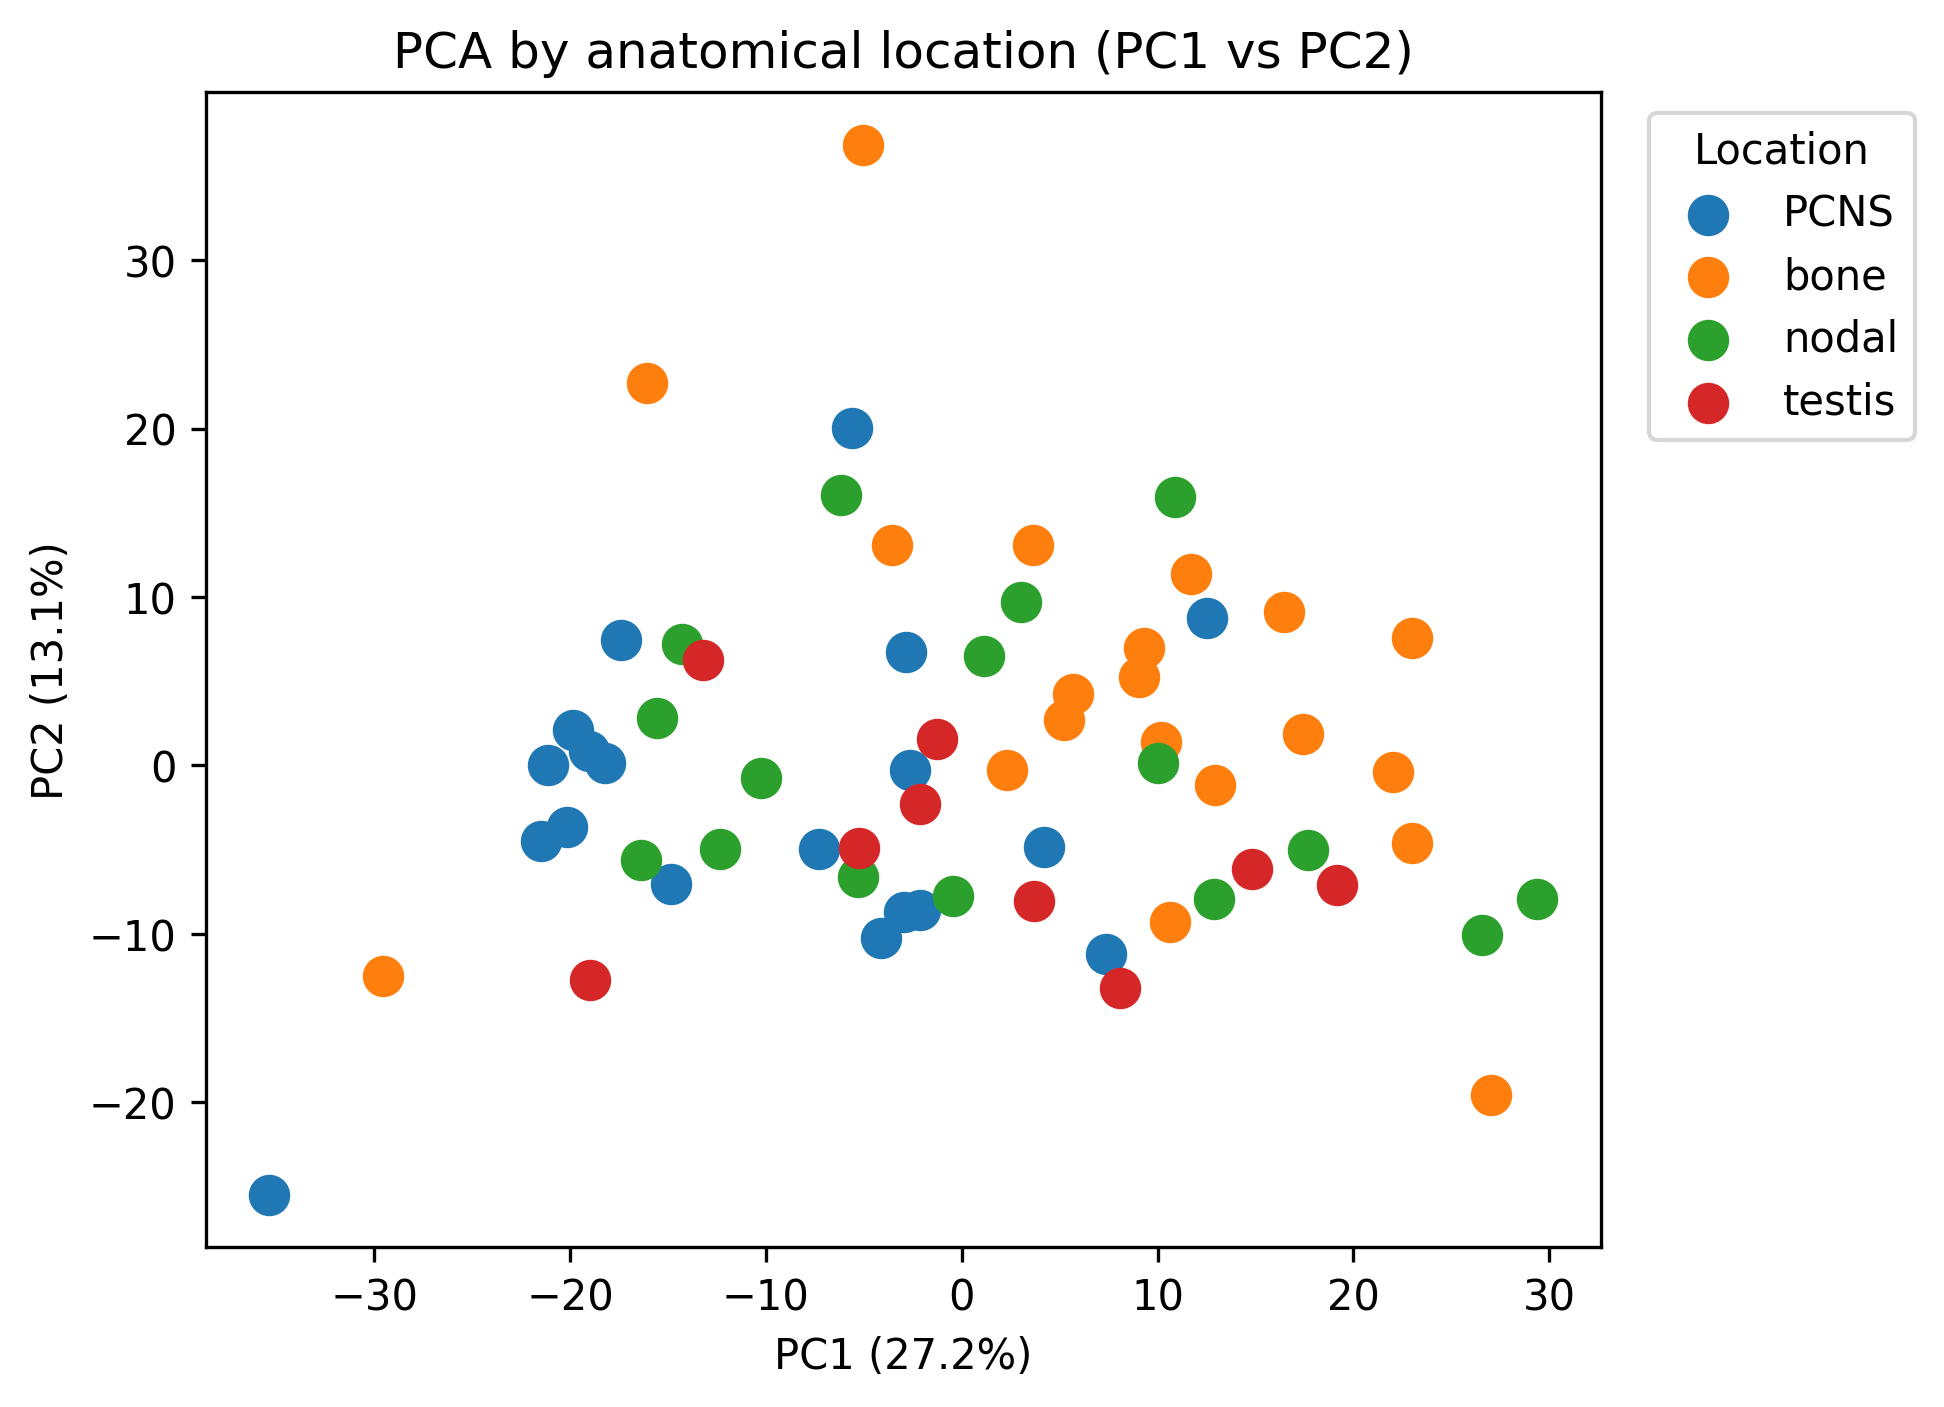

/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/figures/supplemental_fig3/figS3B_PCA_PC1_PC2_location.svg


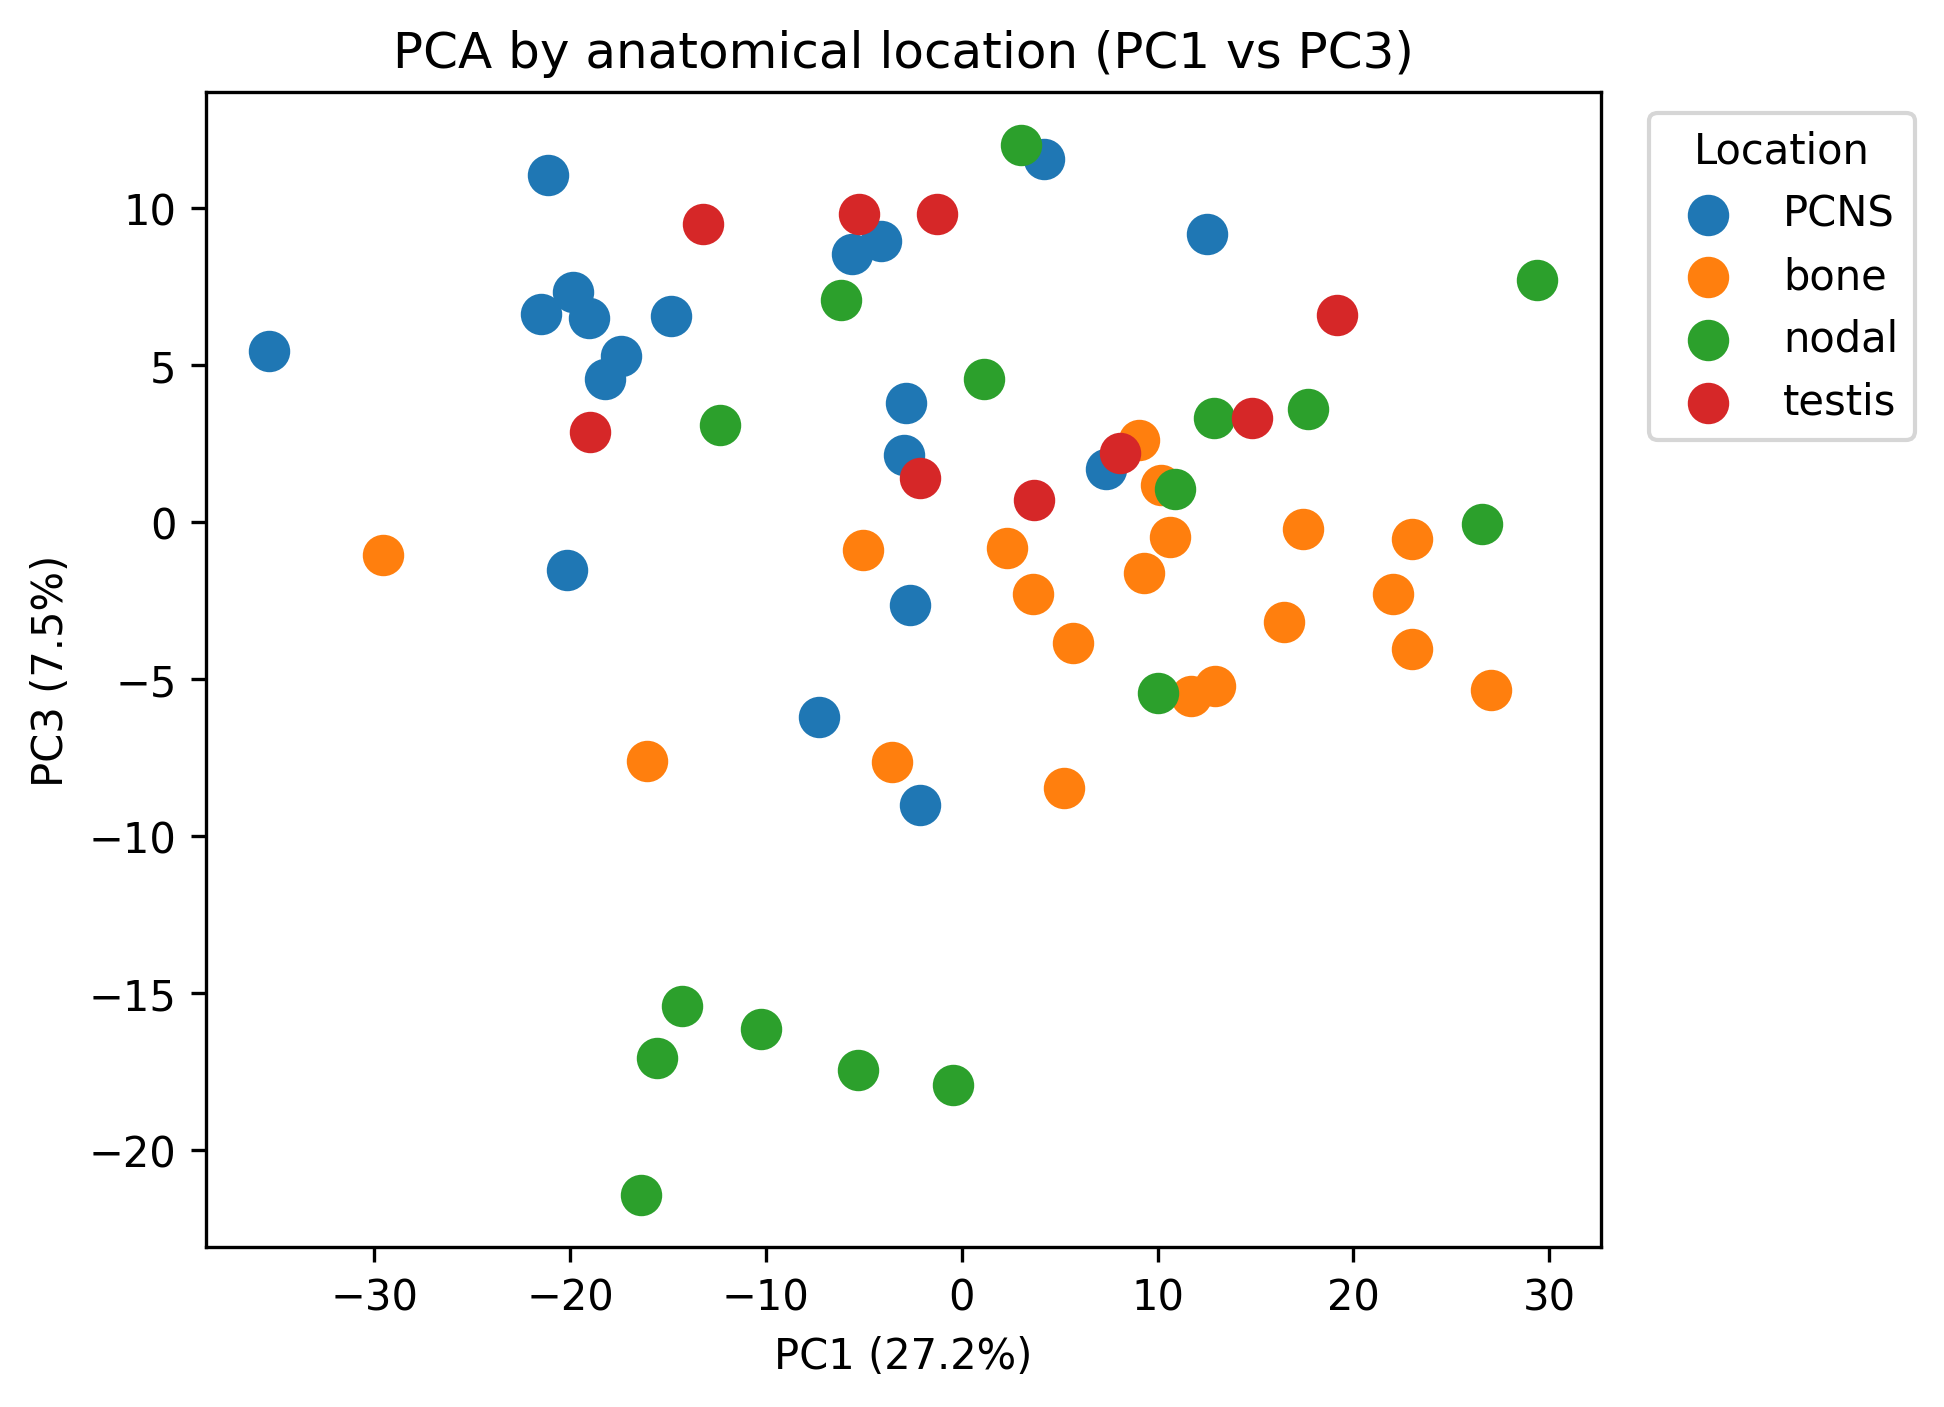

/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/figures/supplemental_fig3/figS3B_PCA_PC1_PC3_location.svg


In [3]:
expr = adata_subset.uns["gene_expression"]

common = expr.columns.astype(str).intersection(meta["patient_id"].astype(str))
X = expr.loc[:, common].T
y_raw = meta.set_index("patient_id").loc[common, "Location"].astype(str)
mask = y_raw.notna() & (y_raw.str.len() > 0) & (y_raw.str.lower() != "nan")
X = X.loc[mask]
y_raw = y_raw.loc[mask]
class_names = sorted(y_raw.unique())

X_np = X.to_numpy(dtype=np.float32)
print(f"PCA input: {X_np.shape[0]} patients × {X_np.shape[1]} genes")
print(y_raw.value_counts().to_string())

pca_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=min(N_PCS_TO_FIT, X_np.shape[0] - 1), random_state=RANDOM_SEED)),
])
X_pca = pca_pipe.fit_transform(X_np)
var_exp = pca_pipe.named_steps["pca"].explained_variance_ratio_

max_pc = max(pc for pair in PLOT_PCS for pc in pair)
pca_df = pd.DataFrame(X_pca[:, :max_pc], index=X.index, columns=[f"PC{i}" for i in range(1, max_pc + 1)])
pca_df["Location"] = y_raw.values

for a, b in PLOT_PCS:
    fig, ax = plt.subplots(figsize=(6, 5))
    for loc in class_names:
        m = pca_df["Location"] == loc
        ax.scatter(pca_df.loc[m, f"PC{a}"], pca_df.loc[m, f"PC{b}"], label=loc, s=80)
    ax.set_xlabel(f"PC{a} ({var_exp[a - 1] * 100:.1f}%)")
    ax.set_ylabel(f"PC{b} ({var_exp[b - 1] * 100:.1f}%)")
    ax.set_title(f"PCA by anatomical location (PC{a} vs PC{b})")
    ax.legend(title="Location", bbox_to_anchor=(1.02, 1), loc="upper left")
    out = FIG_DIR / f"figS3B_PCA_PC{a}_PC{b}_location.svg"
    fig.savefig(out, format="svg", bbox_inches="tight")
    plt.show()
    print(out)


## Fig S3C — phenotype × location standardized residuals


=== Confusion matrix: Location x abundance_cluster_30_label ===


abundance_cluster_30_label,low immune,cytotoxic predominant,complex immune
Location,,,
PCNS,10,8,1
bone,6,2,12
nodal,6,3,7
testis,7,2,0



=== Row-normalized proportions ===


abundance_cluster_30_label,low immune,cytotoxic predominant,complex immune
Location,,,
PCNS,0.526,0.421,0.053
bone,0.300,0.100,0.600
nodal,0.375,0.188,0.438
testis,0.778,0.222,0.000



=== Chi-square test of independence ===
Chi2       : 21.098
p-value    : 1.761e-03
dof        : 6
Cramer's V : 0.406


=== Expected counts ===


abundance_cluster_30_label,low immune,cytotoxic predominant,complex immune
Location,,,
PCNS,8.61,4.45,5.94
bone,9.06,4.69,6.25
nodal,7.25,3.75,5.00
testis,4.08,2.11,2.81



=== Standardized residuals ===


abundance_cluster_30_label,low immune,cytotoxic predominant,complex immune
Location,,,
PCNS,0.47,1.68,-2.03
bone,-1.02,-1.24,2.30
nodal,-0.46,-0.39,0.89
testis,1.45,-0.08,-1.68



=== Enrichment / depletion summary (|residual| >= 2) ===
Enriched: PCNS × cytotoxic predominant (residual=1.68)
Depleted: PCNS × complex immune (residual=-2.03)
Depleted: bone × low immune (residual=-1.02)
Depleted: bone × cytotoxic predominant (residual=-1.24)
Enriched: bone × complex immune (residual=2.30)
Enriched: testis × low immune (residual=1.45)
Depleted: testis × complex immune (residual=-1.68)


Saved SVG to: figures/supplemental_fig3/location_vs_cluster_heatmap.svg


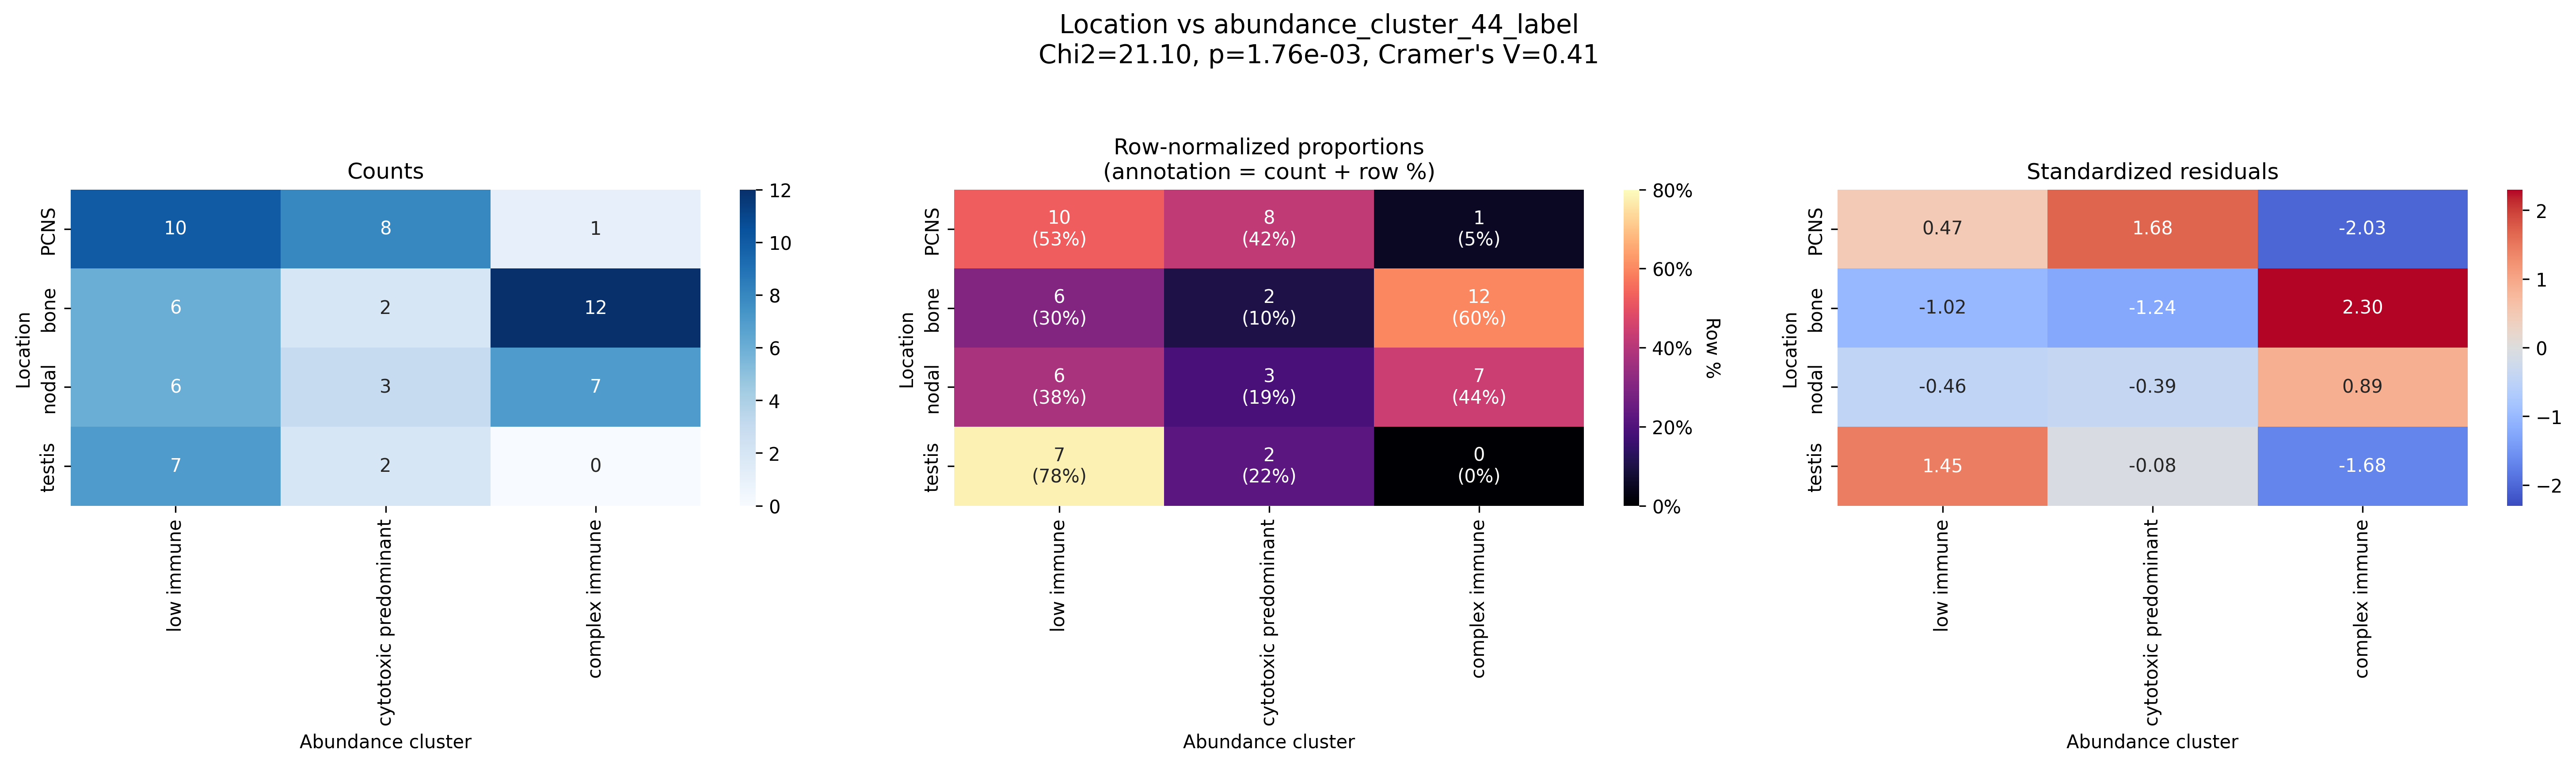

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'
from scipy.stats import chi2_contingency


# -----------------------------
# load metadata
# -----------------------------
meta = pd.DataFrame(adata.uns['case_classifications']).copy()

if 'patient_id' in meta.columns:
    meta = meta.set_index('patient_id')

# collapse location categories to match your other analyses
if 'Location' in meta.columns:
    meta['Location'] = meta['Location'].replace({
        'pBONE': 'bone',
        'polyOST': 'bone',
        'disseminated': 'bone'
    })

# -----------------------------
# pull CURRENT abundance clusters from adata.uns
# -----------------------------
cluster_dict = adata.uns["abundance_cluster_30"]

cluster_name_map = {
    1: "low immune",
    2: "cytotoxic predominant",
    3: "complex immune",
}

meta["abundance_cluster_30"] = meta.index.map(cluster_dict)
meta["abundance_cluster_30_label"] = meta["abundance_cluster_30"].map(cluster_name_map)

# keep only needed columns
df = meta[['Location', 'abundance_cluster_30_label']].dropna().copy()

# optional: enforce biologically sensible order
location_order = ['PCNS', 'bone', 'nodal', 'testis']
cluster_order = ['low immune', 'cytotoxic predominant', 'complex immune']

df['Location'] = pd.Categorical(df['Location'], categories=location_order, ordered=True)
df['abundance_cluster_30_label'] = pd.Categorical(
    df['abundance_cluster_30_label'],
    categories=cluster_order,
    ordered=True
)

# -----------------------------
# confusion matrix
# -----------------------------
ct = pd.crosstab(df['Location'], df['abundance_cluster_30_label'], dropna=False)
ct = ct.loc[ct.sum(axis=1) > 0, ct.sum(axis=0) > 0]

print("\n=== Confusion matrix: Location x abundance_cluster_30_label ===")
display(ct)

# row-normalized proportions
ct_prop = ct.div(ct.sum(axis=1), axis=0)

print("\n=== Row-normalized proportions ===")
display(ct_prop.round(3))

# custom annotation: absolute count + row %
annot_prop = ct.copy().astype(str)
for i in ct.index:
    for j in ct.columns:
        annot_prop.loc[i, j] = f"{ct.loc[i, j]}\n({ct_prop.loc[i, j]*100:.0f}%)"

# -----------------------------
# global association test
# -----------------------------
chi2, p, dof, expected = chi2_contingency(ct)
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)

n = ct.values.sum()
r, k = ct.shape
cramers_v = np.sqrt(chi2 / (n * min(r - 1, k - 1)))

print("\n=== Chi-square test of independence ===")
print(f"Chi2       : {chi2:.3f}")
print(f"p-value    : {p:.3e}")
print(f"dof        : {dof}")
print(f"Cramer's V : {cramers_v:.3f}")

# warning for low expected counts
low_expected = (expected_df < 5).sum().sum()
if low_expected > 0:
    print(f"\nWarning: {low_expected} cells have expected count < 5. Interpret chi-square with caution.")

# -----------------------------
# standardized residuals
# -----------------------------
residuals = (ct - expected_df) / np.sqrt(expected_df)

print("\n=== Expected counts ===")
display(expected_df.round(2))

print("\n=== Standardized residuals ===")
display(residuals.round(2))

# simple textual enrichment summary
print("\n=== Enrichment / depletion summary (|residual| >= 2) ===")
hits = []
for loc in residuals.index:
    for cl in residuals.columns:
        val = residuals.loc[loc, cl]
        if val >= 1:
            hits.append(f"Enriched: {loc} × {cl} (residual={val:.2f})")
        elif val <= -1:
            hits.append(f"Depleted: {loc} × {cl} (residual={val:.2f})")

if hits:
    for h in hits:
        print(h)
else:
    print("No cells with |standardized residual| >= 2.")

# -----------------------------
# plots
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# raw counts
sns.heatmap(
    ct,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    ax=axes[0]
)
axes[0].set_title("Counts")
axes[0].set_xlabel("Abundance cluster")
axes[0].set_ylabel("Location")

# row-normalized proportions, annotated with absolute n + %
import matplotlib.ticker as mtick

hm = sns.heatmap(
    ct_prop,
    annot=annot_prop,
    fmt='',
    cmap='magma',
    vmin=0,
    vmax=0.8,
    cbar=True,
    ax=axes[1]
)

# format colorbar as %
cbar = hm.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
cbar.set_label('Row %', rotation=270, labelpad=15)
cbar.set_ticks(np.linspace(0, 0.8, 5))  # 0%, 20%, 40%, 60%, 80%
axes[1].set_title("Row-normalized proportions\n(annotation = count + row %)")
axes[1].set_xlabel("Abundance cluster")
axes[1].set_ylabel("Location")

# standardized residuals
v = np.nanmax(np.abs(residuals.values))
sns.heatmap(
    residuals,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-v,
    vmax=v,
    cbar=True,
    ax=axes[2]
)
axes[2].set_title("Standardized residuals")
axes[2].set_xlabel("Abundance cluster")
axes[2].set_ylabel("Location")

plt.suptitle(
    f"Location vs abundance_cluster_44_label\n"
    f"Chi2={chi2:.2f}, p={p:.2e}, Cramer's V={cramers_v:.2f}",
    y=1.04,
    fontsize=14
)
plt.tight_layout()
# -----------------------------
# save as SVG
# -----------------------------
svg_path = str(FIG_DIR) + "/location_vs_cluster_heatmap.svg"

plt.savefig(
    svg_path,
    format="svg",
    bbox_inches="tight"
)

print(f"Saved SVG to: {rel_path(svg_path, REPO_ROOT)}")

plt.show()

In [5]:
# Discovery HLA inputs from embedded AnnData (uns gene_expression + case classifications).
DISCOVERY_HLA_OUT = FIG_DIR / "discovery_hla_transcriptome_de"
DISCOVERY_HLA_OUT.mkdir(parents=True, exist_ok=True)
HLA_CLASS_OUT = DISCOVERY_HLA_OUT / "hla_class_groups"
HLA_CLASS_OUT.mkdir(parents=True, exist_ok=True)

hla_expr, hla_meta = tde.build_discovery_hla_transcriptome_inputs(
    adata,
    paths=_paths,
    patient_subset=PATIENT_SUBSET,
)
hla_meta_class = tde.add_hla_class_group(hla_meta)
print(
    f"HLA cohort: {hla_expr.shape[0]} patients × {hla_expr.shape[1]} genes | "
    f"class groups: {hla_meta_class['hla_class_group'].dropna().nunique()}"
)


HLA cohort: 64 patients × 797 genes | class groups: 3


## Fig S3D — HLA class status × immune gene programs

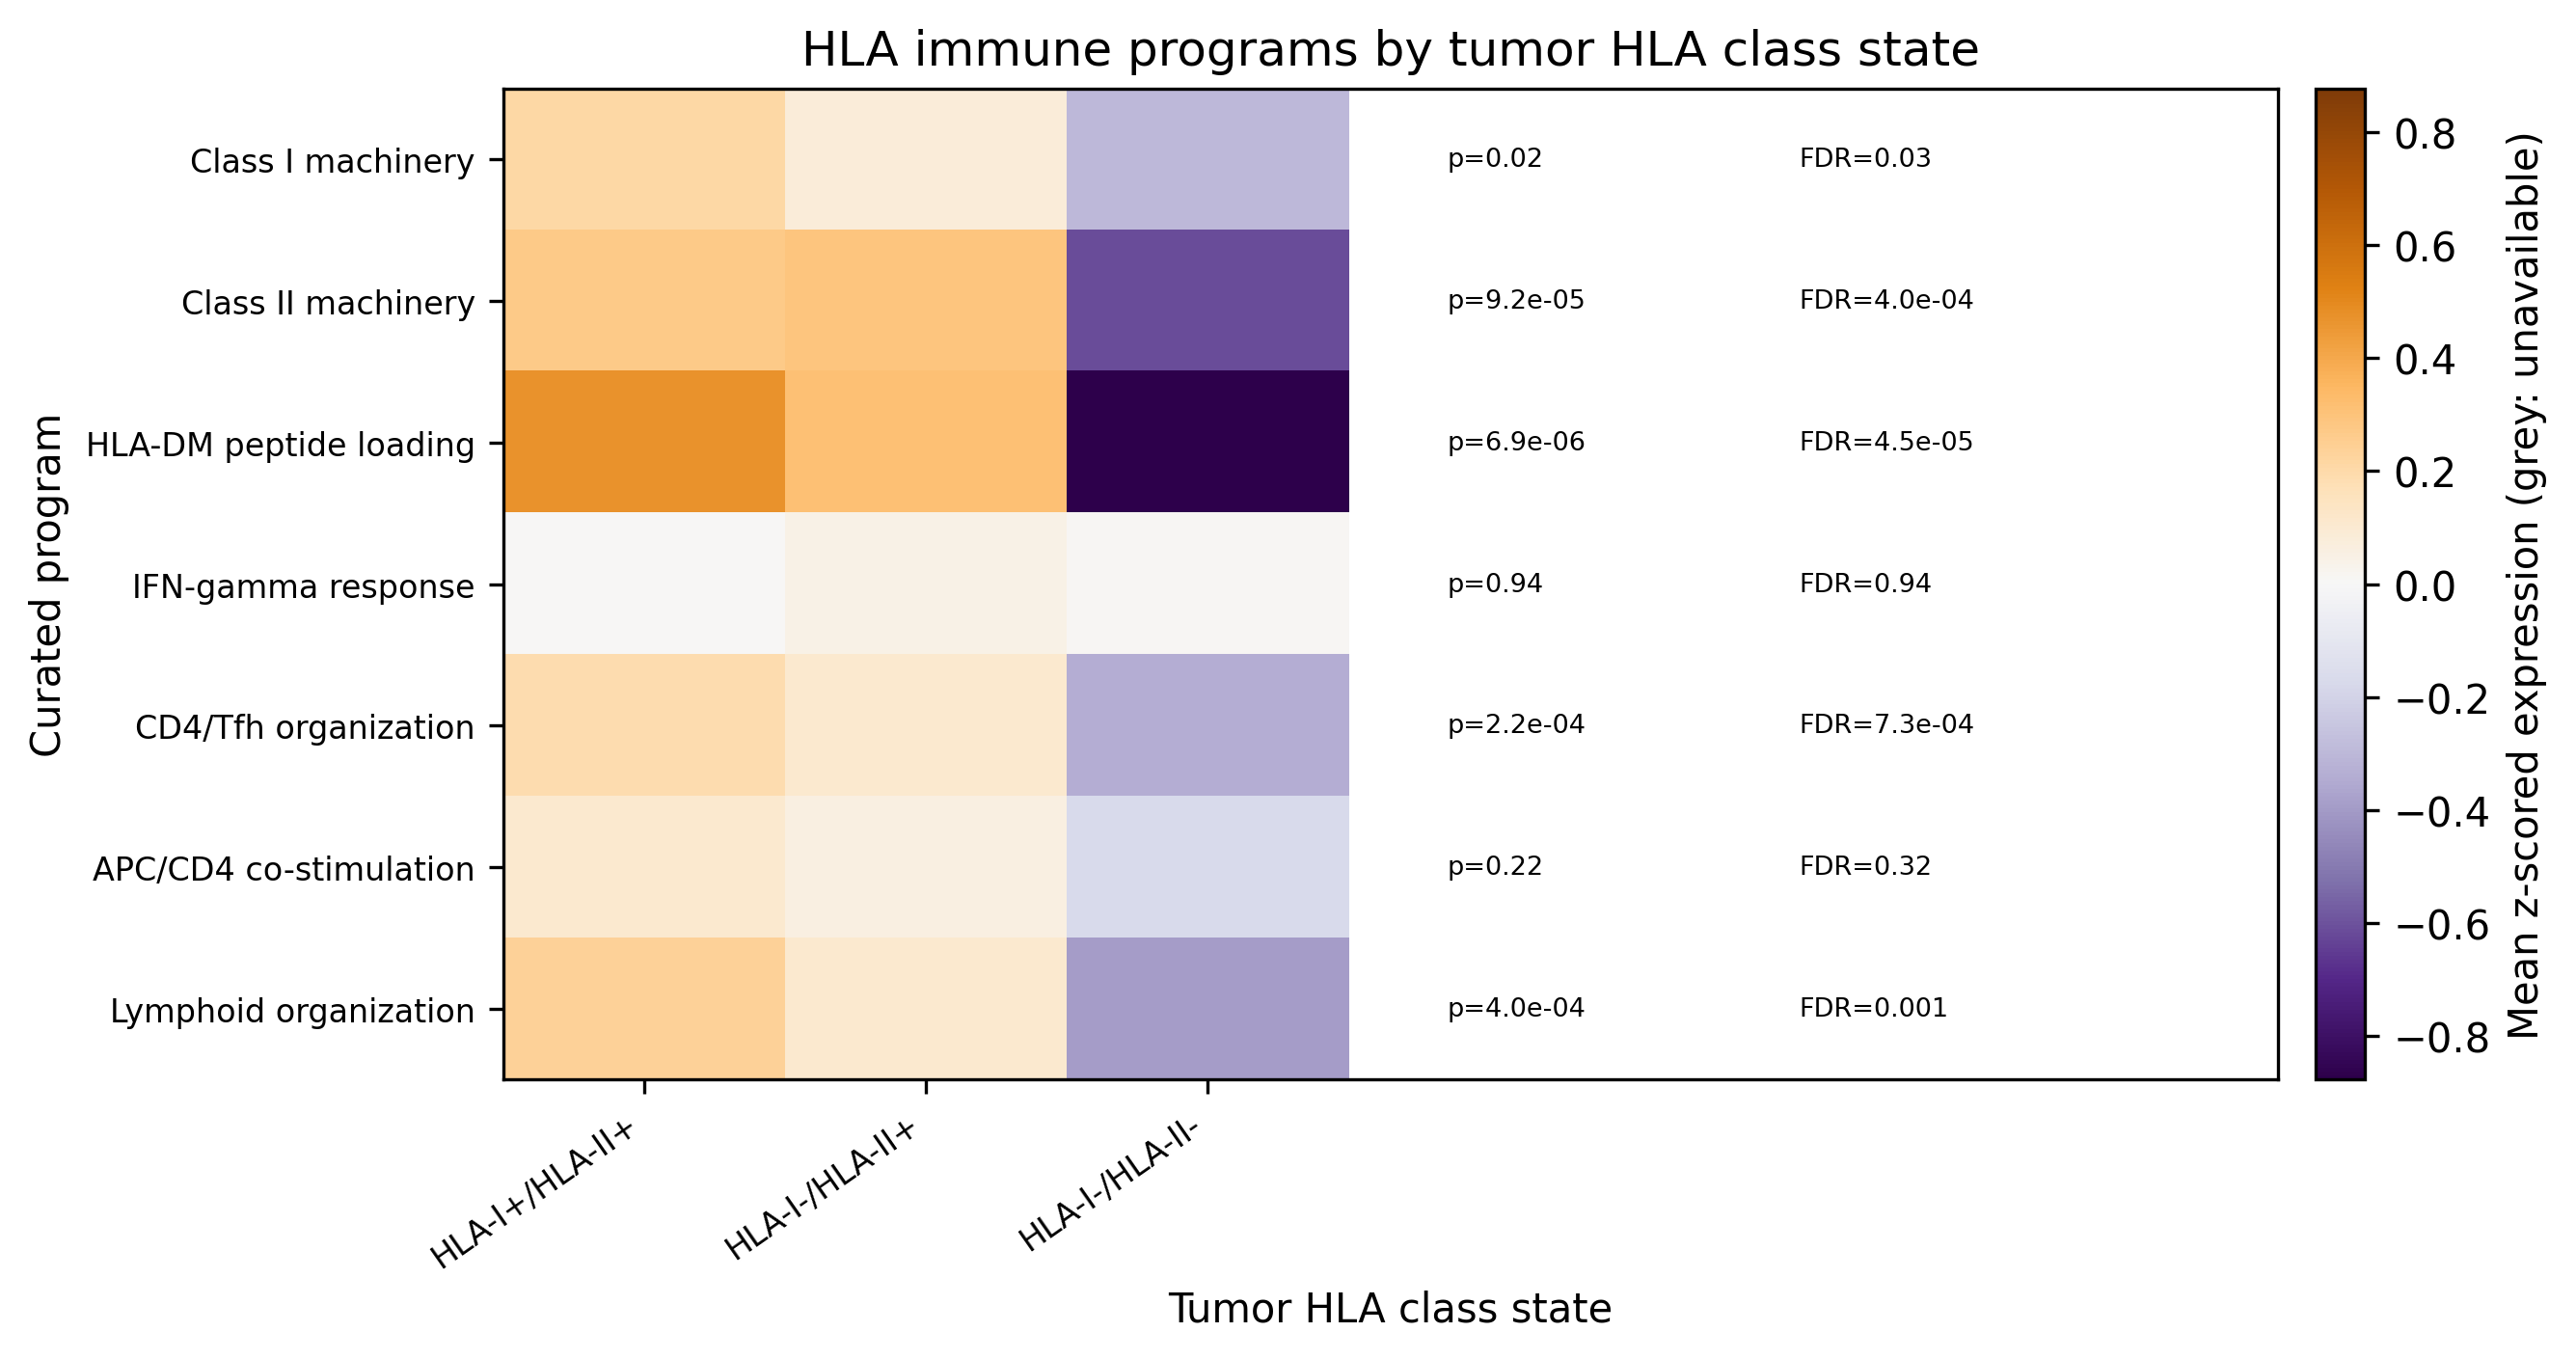

Saved: figures/supplemental_fig3/discovery_hla_transcriptome_de/hla_class_groups/discovery_hla_class_group_hla_immune_program_mean_zscore_heatmap.svg


,program,kruskal_H,p,max_group,max_median,min_group,min_median,median_Ipos_IIpos,n_Ipos_IIpos,median_Ipos_IIneg,n_Ipos_IIneg,median_Ineg_IIpos,n_Ineg_IIpos,median_Ineg_IIneg,n_Ineg_IIneg,q
10,APC-like myeloid / DC,24.012289,0.000006,HLA-I+/HLA-II+,0.537028,HLA-I-/HLA-II-,-0.890323,0.537028,24,NaN,0,0.281372,19,-0.890323,20,0.000045
2,HLA-DM peptide loading,23.778915,0.000007,HLA-I+/HLA-II+,0.410522,HLA-I-/HLA-II-,-0.796314,0.410522,24,NaN,0,0.336986,19,-0.796314,20,0.000045
1,Class II machinery,18.592022,0.000092,HLA-I+/HLA-II+,0.353734,HLA-I-/HLA-II-,-0.769530,0.353734,24,NaN,0,0.315863,19,-0.769530,20,0.000398
5,CD4/Tfh organization,16.808011,0.000224,HLA-I-/HLA-II+,0.242193,HLA-I-/HLA-II-,-0.336183,0.141344,24,NaN,0,0.242193,19,-0.336183,20,0.000728
12,Lymphoid organization,15.636590,0.000402,HLA-I-/HLA-II+,0.232237,HLA-I-/HLA-II-,-0.294436,0.178447,24,NaN,0,0.232237,19,-0.294436,20,0.001046
0,Class I machinery,8.269352,0.016008,HLA-I+/HLA-II+,0.239330,HLA-I-/HLA-II-,-0.184722,0.239330,24,NaN,0,-0.022541,19,-0.184722,20,0.034684
8,Exhaustion,4.790510,0.091149,HLA-I+/HLA-II+,0.206590,HLA-I-/HLA-II-,-0.189522,0.206590,24,NaN,0,-0.033064,19,-0.189522,20,0.169278
6,APC/CD4 co-stimulation,3.060521,0.216479,HLA-I+/HLA-II+,0.148078,HLA-I-/HLA-II-,-0.054522,0.148078,24,NaN,0,0.010509,19,-0.054522,20,0.317937
11,Suppressive myeloid,3.027254,0.220110,HLA-I-/HLA-II-,0.077410,HLA-I+/HLA-II+,-0.249699,-0.249699,24,NaN,0,-0.192706,19,0.077410,20,0.317937
7,Cytotoxicity,1.369055,0.504328,HLA-I-/HLA-II-,0.160394,HLA-I-/HLA-II+,-0.100748,0.049014,24,NaN,0,-0.100748,19,0.160394,20,0.655627


In [6]:
hla_program_scores, hla_program_presence = tde.compute_program_scores(
    hla_expr,
    programs=tde.HLA_IMMUNE_PROGRAM_GENE_SETS,
    min_genes=1,
)
hla_program_mean_matrix = tde.hla_class_group_program_mean_matrix(hla_program_scores, hla_meta_class)
hla_program_score_long = tde.hla_class_group_program_score_long(hla_program_scores, hla_meta_class)
hla_program_score_tests = tde.run_hla_class_group_feature_tests(
    hla_program_score_long,
    feature_col="program",
    value_col="score",
)
hla_program_heatmap_rows = tde.HLA_CLASS_GROUP_PROGRAM_HEATMAP_ORDER
hla_program_mean_heatmap = HLA_CLASS_OUT / "discovery_hla_class_group_hla_immune_program_mean_zscore_heatmap.svg"
tde.plot_hla_class_group_program_heatmap(
    hla_program_mean_matrix.reindex(hla_program_heatmap_rows),
    None,
    hla_program_mean_heatmap,
    value_label="Mean z-scored expression",
    title="HLA immune programs by tumor HLA class state",
    row_stats_table=hla_program_score_tests,
    cmap_name="PuOr_r",
    show=True,
)
log_saved(hla_program_mean_heatmap, REPO_ROOT)
display(hla_program_score_tests)


## Fig S3E — HLA class status × phenotypes

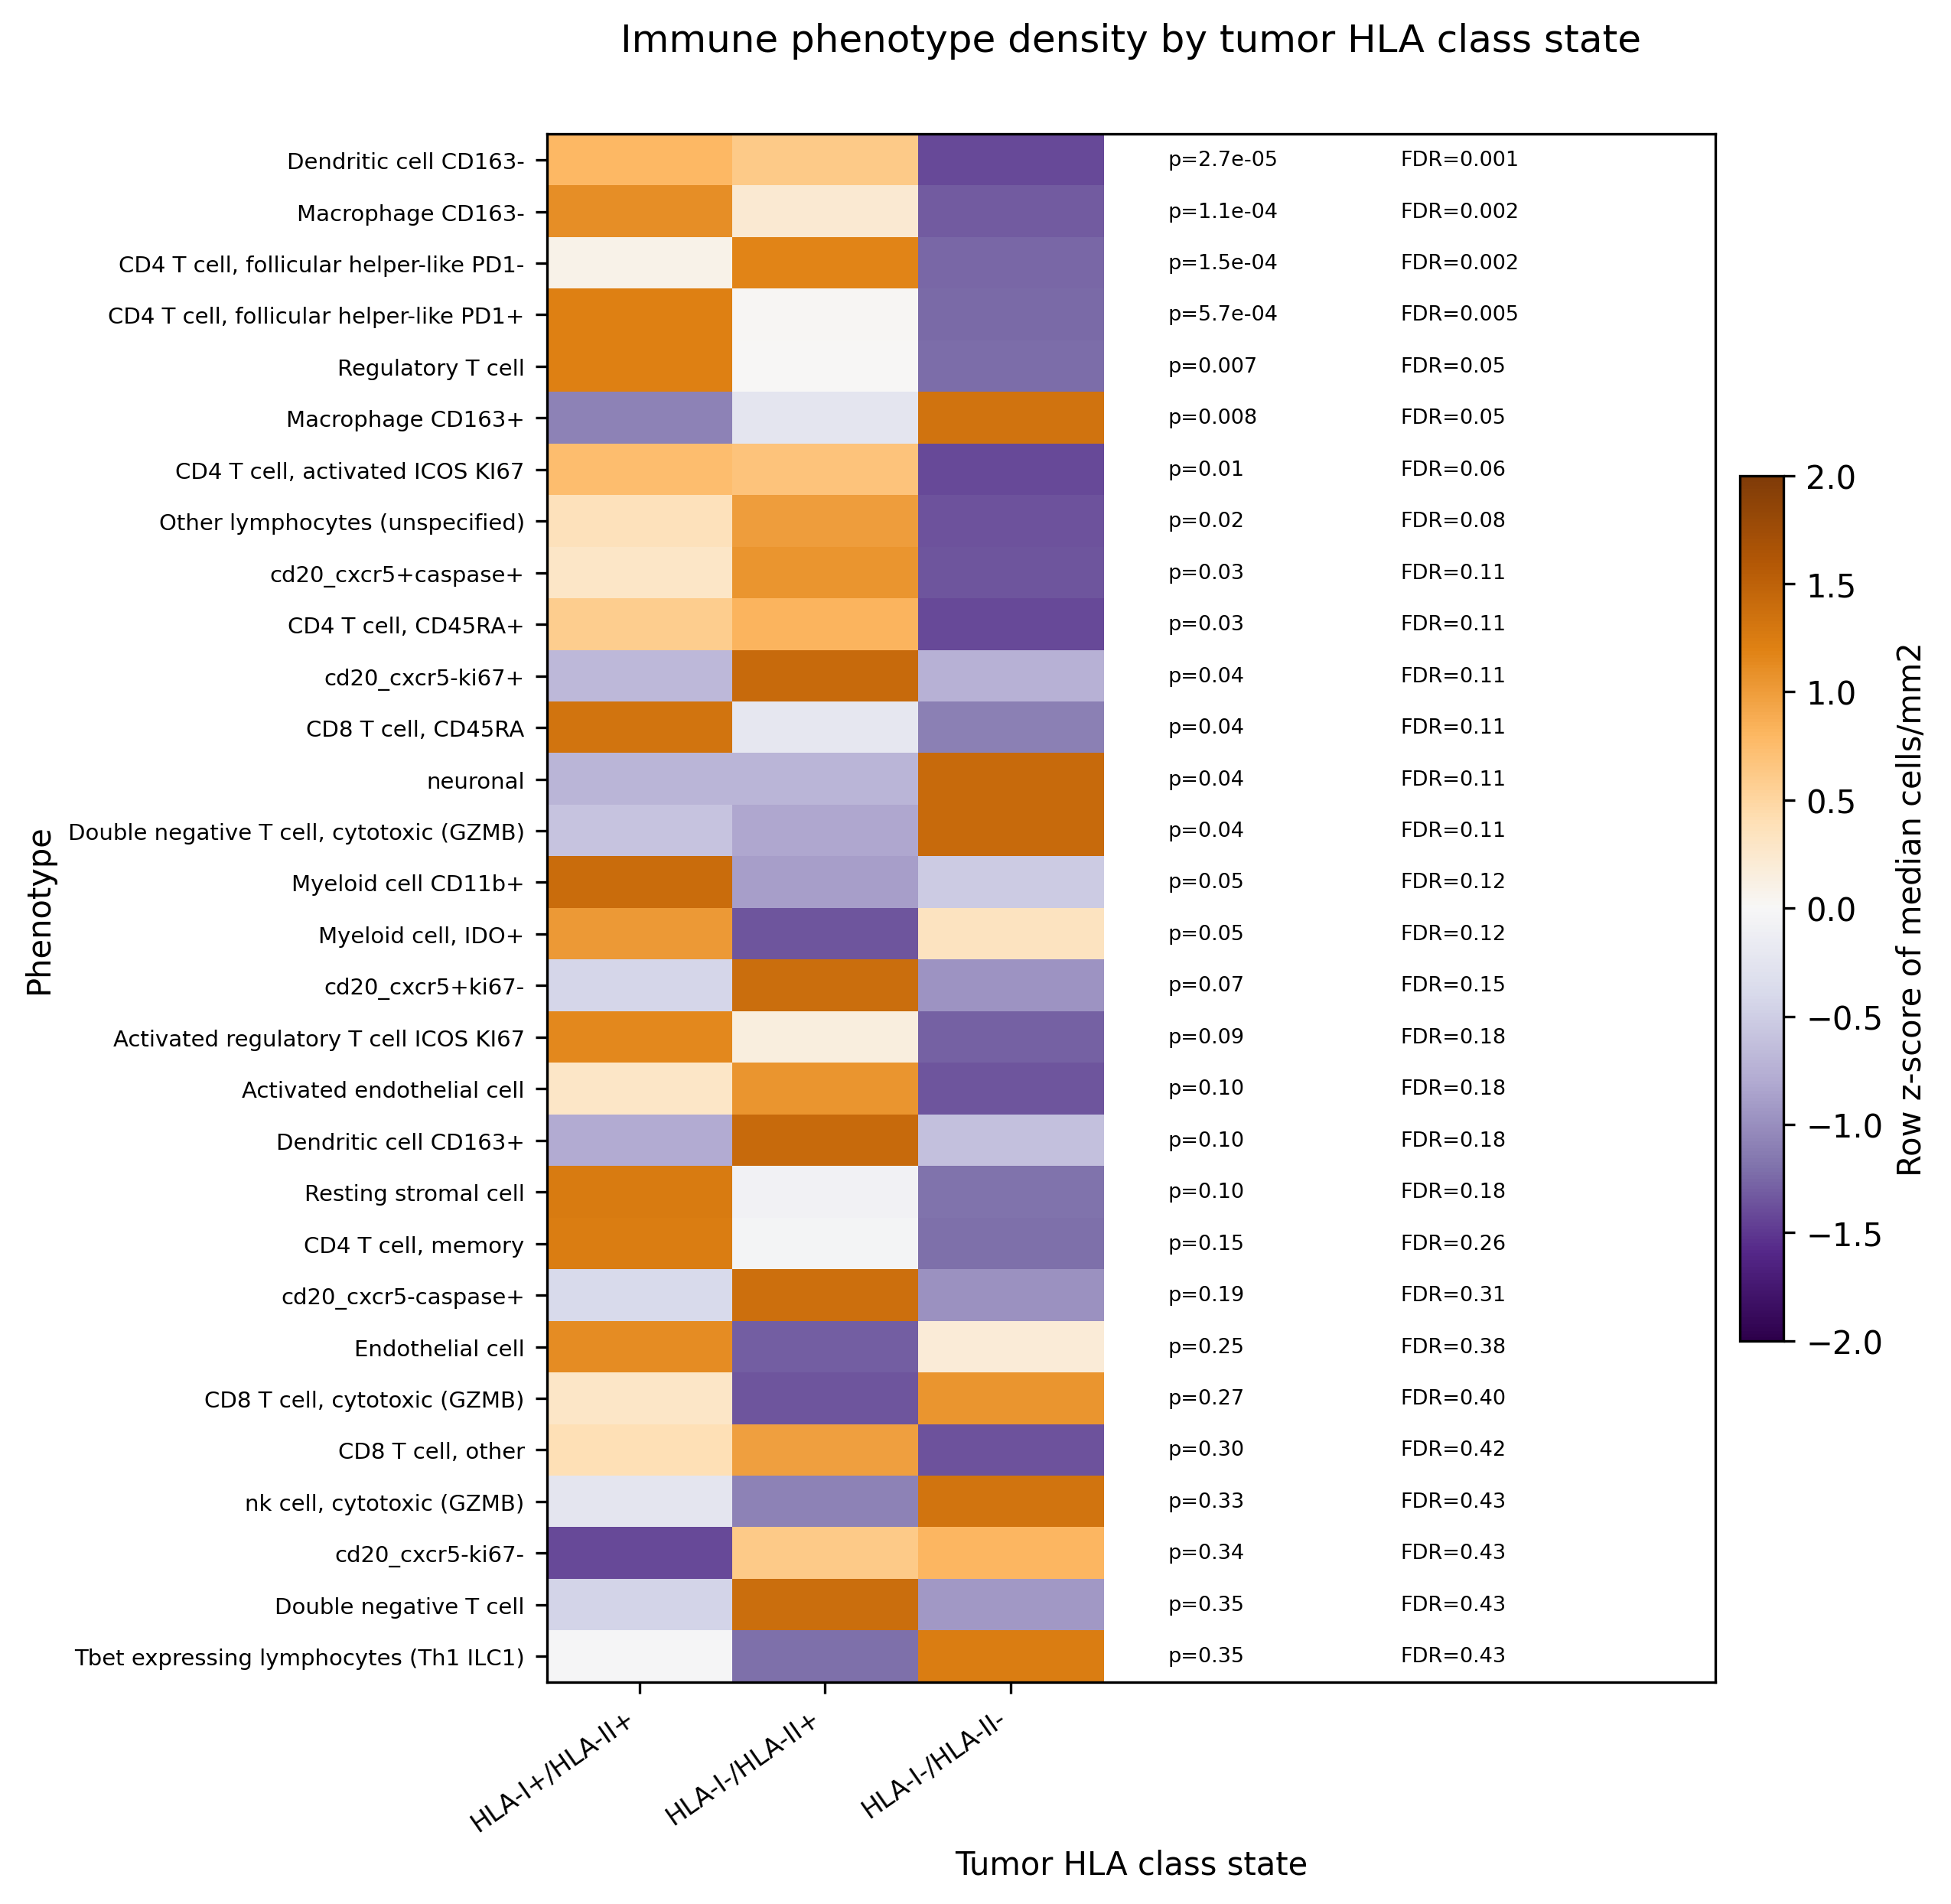

Saved: figures/supplemental_fig3/discovery_hla_transcriptome_de/hla_class_groups/discovery_hla_class_group_phenotype_density_heatmap.svg


,phenotype,kruskal_H,p,max_group,max_median_density,min_group,min_median_density,median_Ipos_IIpos,n_Ipos_IIpos,median_Ipos_IIneg,n_Ipos_IIneg,median_Ineg_IIpos,n_Ineg_IIpos,median_Ineg_IIneg,n_Ineg_IIneg,q
12,Dendritic cell CD163-,21.034322,0.000027,HLA-I+/HLA-II+,16.155585,HLA-I-/HLA-II-,2.451274,16.155585,24,NaN,0,15.089981,19,2.451274,20,0.001002
18,Macrophage CD163-,18.311666,0.000106,HLA-I+/HLA-II+,257.524889,HLA-I-/HLA-II-,137.010227,257.524889,24,NaN,0,214.117799,19,137.010227,20,0.001886
6,"CD4 T cell, follicular helper-like PD1-",17.571463,0.000153,HLA-I-/HLA-II+,61.182795,HLA-I-/HLA-II-,12.903357,39.509706,24,NaN,0,61.182795,19,12.903357,20,0.001886
5,"CD4 T cell, follicular helper-like PD1+",14.956062,0.000565,HLA-I+/HLA-II+,4.899451,HLA-I-/HLA-II-,1.217251,4.899451,24,NaN,0,3.105048,19,1.217251,20,0.005230
25,Regulatory T cell,9.897914,0.007091,HLA-I+/HLA-II+,43.072075,HLA-I-/HLA-II-,10.891625,43.072075,24,NaN,0,27.252086,19,10.891625,20,0.048958
17,Macrophage CD163+,9.671921,0.007939,HLA-I-/HLA-II-,186.144018,HLA-I+/HLA-II+,74.794406,74.794406,24,NaN,0,113.598928,19,186.144018,20,0.048958
4,"CD4 T cell, activated ICOS KI67",8.841389,0.012026,HLA-I+/HLA-II+,18.856603,HLA-I-/HLA-II-,7.175639,18.856603,24,NaN,0,18.503488,19,7.175639,20,0.063565
24,Other lymphocytes (unspecified),8.042073,0.017934,HLA-I-/HLA-II+,492.084476,HLA-I-/HLA-II-,214.798189,418.548482,24,NaN,0,492.084476,19,214.798189,20,0.082946
28,cd20_cxcr5+caspase+,7.130791,0.028286,HLA-I-/HLA-II+,241.446893,HLA-I-/HLA-II-,93.413844,194.786043,24,NaN,0,241.446893,19,93.413844,20,0.111627
3,"CD4 T cell, CD45RA+",6.736166,0.034456,HLA-I-/HLA-II+,15.525238,HLA-I-/HLA-II-,4.939609,14.411833,24,NaN,0,15.525238,19,4.939609,20,0.111627


In [7]:
phenotype_density, hla_class_area = tde.compute_patient_phenotype_densities(
    adata,
    hla_meta_class,
    phenotype_col="phenotype_30_clean",
    pixel_size_um=1.0,
    patient_subset=PATIENT_SUBSET,
)
hla_class_density_tests = tde.run_hla_class_group_density_tests(phenotype_density)
hla_class_density_matrix = tde.hla_class_group_density_matrix(phenotype_density)
hla_class_density_heatmap = HLA_CLASS_OUT / "discovery_hla_class_group_phenotype_density_heatmap.svg"
tde.plot_hla_class_group_density_heatmap(
    hla_class_density_matrix,
    hla_class_density_tests,
    hla_class_density_heatmap,
    top_n=30,
    q_th=0.05,
    row_stats_table=hla_class_density_tests,
    cmap_name="PuOr_r",
    show=True,
)
log_saved(hla_class_density_heatmap, REPO_ROOT)
display(hla_class_density_tests.head(30))


## Fig S3F — cell of origin (COO) tSNE

In [8]:
map_patient_column(adata_subset, "COO_NanoString", "coo")
adata_filt = adata_subset[valid_label_mask(adata_subset.obs["coo"])]
adata_plot = adata_filt[downsample_indices(adata_filt.n_obs)]
rng = np.random.default_rng(PLOT_SEED)
sort_order = rng.permutation(adata_plot.n_obs).tolist()

plot_tsne(
    adata_plot,
    color="coo",
    title="tSNE — cell of origin",
    out_stem=FIG_DIR / "figS3F_tsne_coo",
    palette=["#0072B2", "#E69F00", "#CC79A7", "#009E73"],
    sort_order=sort_order,
)


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


figures/supplemental_fig3/figS3F_tsne_coo.svg


## Fig S3G — lymphoMAP tSNE

In [9]:
map_patient_column(adata_subset, "lymphomap", "lymphomap")
adata_filt = adata_subset[valid_label_mask(adata_subset.obs["lymphomap"])]
adata_plot = adata_filt[downsample_indices(adata_filt.n_obs)]
rng = np.random.default_rng(PLOT_SEED)
sort_order = rng.permutation(adata_plot.n_obs).tolist()

plot_tsne(
    adata_plot,
    color="lymphomap",
    title="tSNE — lymphoMAP",
    out_stem=FIG_DIR / "figS3G_tsne_lymphomap",
    palette=["#0072B2", "#E69F00", "#CC79A7", "#009E73"],
    sort_order=sort_order,
)


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


figures/supplemental_fig3/figS3G_tsne_lymphomap.svg


## Fig S3H — immune archetype tSNE

In [10]:
map_patient_column(adata_subset, "abundance_cluster", "ecotype")
adata_filt = adata_subset[valid_label_mask(adata_subset.obs["ecotype"])]
adata_plot = adata_filt[downsample_indices(adata_filt.n_obs)]
rng = np.random.default_rng(PLOT_SEED)
sort_order = rng.permutation(adata_plot.n_obs).tolist()

plot_tsne(
    adata_plot,
    color="ecotype",
    title="tSNE — immune archetype",
    out_stem=FIG_DIR / "figS3H_tsne_archetype",
    palette=["#E69F00", "#CC79A7", "#009E73"],
    sort_order=sort_order,
)


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


figures/supplemental_fig3/figS3H_tsne_archetype.svg


## Fig S3J — immune-archetype classifier confusion matrix

Nested cross-validation and the aggregated out-of-fold confusion matrix are generated in **`fig5.ipynb`** (Fig 5H).

Outputs: `figures/fig5/confusion_elasticnet_cluster_assignment_named.svg` and `location_elasticnet_confusion_matrix.csv`.